In [35]:
import pandas as pd
import numpy as np
import os
from google.colab import drive
import warnings
from datetime import datetime
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
np.random.seed(42)

In [36]:
# Mount Google Drive
drive.mount('/content/drive', force_remount=True)

# Change working directory to project folder
try:
    os.chdir("/content/drive/MyDrive/UAB/FDS/campus-waste-intelligence")
    print("Directory changed successfully")
except OSError:
    print("Error: Can't change the Current Working Directory")

Mounted at /content/drive
Directory changed successfully


In [4]:
df = pd.read_csv("data/food_waste_features.csv", parse_dates=['time_bin'])

print(f"Raw shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"Canteen sections: {df['Canteen_Section'].unique()}")
df.head()

Raw shape: (74413, 7)
Columns: ['Canteen_Section', 'time_bin', 'Waste_Weight_kg', 'Cost_Loss', 'Foot_Traffic', 'is_holiday', 'is_special_day']
Canteen sections: ['A' 'B' 'C' 'D']


,Canteen_Section,time_bin,Waste_Weight_kg,Cost_Loss,Foot_Traffic,is_holiday,is_special_day
0,A,2015-01-01 12:00:00,2.98,5.96,120.0,1,1
1,A,2015-01-01 17:30:00,1.15,3.44,100.0,1,1
2,A,2015-01-01 18:00:00,0.93,2.78,100.0,1,1
3,A,2015-01-02 06:00:00,0.44,1.33,80.0,0,0
4,A,2015-01-02 12:00:00,1.54,4.62,120.0,0,0


## Moving Averages Baseline Model for Waste Prediction

This section will focus on creating a simple moving average baseline model to predict waste generation. We will create helper functions for feature engineering and evaluation, ensuring proper data splitting to avoid data leakage.

In [37]:
def create_moving_average_features(data, window_size):
    df_copy = data.copy()
    df_copy = df_copy.sort_values(by=['Canteen_Section', 'time_bin'])

    df_copy[f'Waste_MA_{window_size}'] = df_copy.groupby('Canteen_Section')['Waste_Weight_kg'].transform(lambda x: x.shift(1).rolling(window=window_size).mean())

    return df_copy

### Prepare Data with Moving Average Features

We will add a 7-day moving average as a feature. This average will be shifted by one day to ensure that only past data is used for prediction, preventing data leakage.

### Hyperparameters

In [38]:
# Define hyperparameters here
window_size = 7
split_date = pd.to_datetime('2018-01-01') # Example split date, adjust as needed

In [39]:
# Apply the helper function to create moving average features
df_ma = create_moving_average_features(df, window_size)

# Drop rows with NaN values introduced by the moving average calculation
df_ma.dropna(subset=[f'Waste_MA_{window_size}'], inplace=True)

print(f"DataFrame shape after adding moving average: {df_ma.shape}")
display(df_ma.head())

DataFrame shape after adding moving average: (74385, 8)


,Canteen_Section,time_bin,Waste_Weight_kg,Cost_Loss,Foot_Traffic,is_holiday,is_special_day,Waste_MA_7
7,A,2015-01-03 06:30:00,4.12,8.23,56.0,0,1,1.894286
8,A,2015-01-03 08:30:00,1.96,15.66,56.0,0,1,2.057143
9,A,2015-01-03 11:30:00,0.65,0.98,84.0,0,1,2.172857
10,A,2015-01-03 12:30:00,5.00,15.00,84.0,0,1,2.132857
11,A,2015-01-03 18:00:00,1.81,14.45,70.0,0,1,2.784286


### Data Splitting (Train/Test) to Avoid Leakage

To prevent data leakage, we will split the data based on time. All data before a specific `split_date` will be used for training, and data on or after this date will be used for testing. This simulates a real-world prediction scenario where we only have access to past data.

In [40]:
# Define a split date to separate training and testing data
train_df = df_ma[df_ma['time_bin'] < split_date].copy()
test_df = df_ma[df_ma['time_bin'] >= split_date].copy()

print(f"Training data shape: {train_df.shape}")
print(f"Testing data shape: {test_df.shape}")

print(f"Training data date range: {train_df['time_bin'].min()} to {train_df['time_bin'].max()}")
print(f"Testing data date range: {test_df['time_bin'].min()} to {test_df['time_bin'].max()}")

Training data shape: (21049, 8)
Testing data shape: (53336, 8)
Training data date range: 2015-01-02 08:30:00 to 2017-12-31 19:30:00
Testing data date range: 2018-01-01 06:00:00 to 2025-08-10 19:30:00


### Baseline Model: Moving Average Prediction

For our baseline, the prediction for 'Waste_Weight_kg' will simply be the `Waste_MA_7` feature we created. We don't need a formal 'training' step as the feature itself is the prediction.

In [41]:
# The baseline model's prediction is the moving average itself
test_df['Waste_Prediction'] = test_df[f'Waste_MA_{window_size}']

display(test_df[['time_bin', 'Canteen_Section', 'Waste_Weight_kg', f'Waste_MA_{window_size}', 'Waste_Prediction']].head())

,time_bin,Canteen_Section,Waste_Weight_kg,Waste_MA_7,Waste_Prediction
5368,2018-01-01 07:00:00,A,2.36,2.551429,2.551429
5369,2018-01-01 07:30:00,A,5.00,2.200000,2.200000
5370,2018-01-01 08:00:00,A,1.39,2.574286,2.574286
5371,2018-01-01 19:00:00,A,2.40,2.711429,2.711429
5372,2018-01-01 19:30:00,A,2.42,2.340000,2.340000


### Helper Function for Model Evaluation

We will define a function to calculate Root Mean Squared Error (RMSE), Mean Squared Error (MSE), and R-squared (R2) for model performance evaluation.

In [42]:
def evaluate_model(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    return {'RMSE': rmse, 'MSE': mse, 'R2': r2}

### Evaluate Baseline Model Performance

Now, let's evaluate our moving average baseline model on the test set.

In [10]:
y_true = test_df['Waste_Weight_kg']
y_pred = test_df['Waste_Prediction']

performance_metrics = evaluate_model(y_true, y_pred)

print("Baseline Model Performance on Test Set:")
for metric, value in performance_metrics.items():
    print(f"{metric}: {value:.4f}")

Baseline Model Performance on Test Set:
RMSE: 1.6727
MSE: 2.7980
R2: -0.1402


### Visualize Actual vs. Predicted Waste for a Week

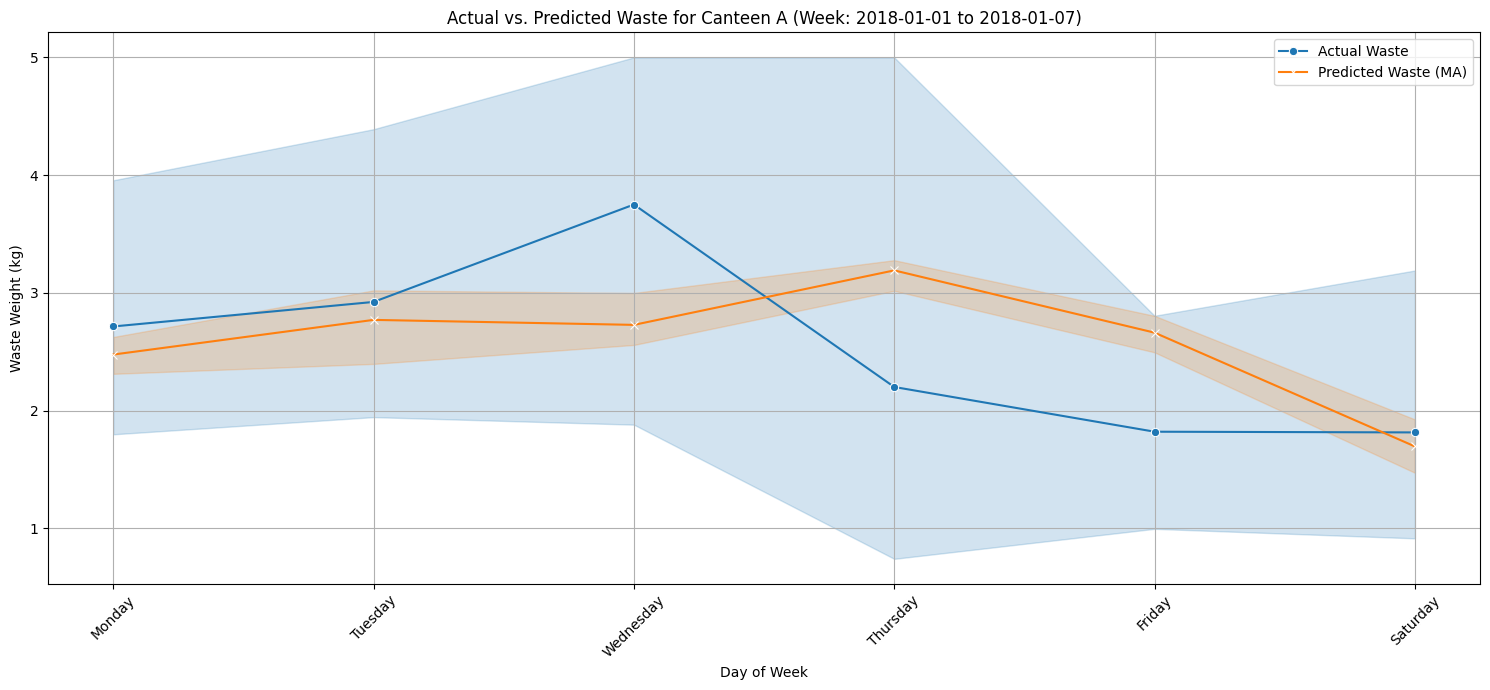

In [43]:
selected_canteen = 'A'
start_visual_date = split_date # Use the defined split_date for consistency
end_visual_date = start_visual_date + pd.Timedelta(days=6)

# Filter test_df for the selected canteen and date range
plot_df = test_df[
    (test_df['Canteen_Section'] == selected_canteen) &
    (test_df['time_bin'] >= start_visual_date) &
    (test_df['time_bin'] <= end_visual_date)
].copy()

# Explicitly add Waste_Prediction to plot_df, as it might be missing due to slicing/copying
# or if test_df was modified after plot_df was created.
if 'Waste_Prediction' not in plot_df.columns:
    plot_df['Waste_Prediction'] = plot_df[f'Waste_MA_{window_size}']

# Add 'DayOfWeek' column for x-axis
plot_df['DayOfWeek'] = plot_df['time_bin'].dt.day_name()

plt.figure(figsize=(15, 7))
sns.lineplot(x='DayOfWeek', y='Waste_Weight_kg', data=plot_df, label='Actual Waste', marker='o')
sns.lineplot(x='DayOfWeek', y='Waste_Prediction', data=plot_df, label='Predicted Waste (MA)', marker='x')

plt.title(f'Actual vs. Predicted Waste for Canteen {selected_canteen} (Week: {start_visual_date.date()} to {end_visual_date.date()})')
plt.xlabel('Day of Week')
plt.ylabel('Waste Weight (kg)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Predict Waste for the Next Week

Now, let's demonstrate how to use this model to predict waste for the next one week, starting from a given date. We'll simulate predicting future dates by extending the `test_df` and applying the moving average logic.

In [44]:
def predict_next_week(df_historical, start_prediction_date, window_size=7):
    start_prediction_date = pd.to_datetime(start_prediction_date)
    prediction_end_date = start_prediction_date + pd.Timedelta(days=6)

    unique_canteen_sections = df_historical['Canteen_Section'].unique()
    time_intervals_per_day = df_historical[df_historical['Canteen_Section'] == unique_canteen_sections[0]]['time_bin'].diff().mode()[0]

    future_time_bins = []
    current_date = start_prediction_date
    while current_date <= prediction_end_date:
        daily_time_bins = df_historical[(df_historical['time_bin'].dt.date == df_historical['time_bin'].max().date())]['time_bin'].dt.time.unique()
        for time_of_day in daily_time_bins:
            future_time_bins.append(datetime.combine(current_date.date(), time_of_day))
        current_date += pd.Timedelta(days=1);

    future_df = pd.DataFrame({
        'time_bin': future_time_bins
    })
    future_df = future_df.sort_values(by='time_bin')

    future_df_expanded = pd.DataFrame()
    for section in unique_canteen_sections:
        temp_df = future_df.copy()
        temp_df['Canteen_Section'] = section
        future_df_expanded = pd.concat([future_df_expanded, temp_df])

    future_df_expanded = future_df_expanded.sort_values(by=['Canteen_Section', 'time_bin'])

    predictions = []
    for section in unique_canteen_sections:
        last_ma_value = df_historical[df_historical['Canteen_Section'] == section].iloc[-1][f'Waste_MA_{window_size}']

        section_future_df = future_df_expanded[future_df_expanded['Canteen_Section'] == section].copy()
        section_future_df['Predicted_Waste_Weight_kg'] = last_ma_value
        predictions.append(section_future_df)

    return pd.concat(predictions).reset_index(drop=True)

In [45]:
start_prediction_date = train_df['time_bin'].max() + pd.Timedelta(days=1)

print(f"Predicting for the week starting: {start_prediction_date.date()}")

# Generate predictions for the next week
next_week_predictions = predict_next_week(train_df, start_prediction_date, window_size)

display(next_week_predictions)

Predicting for the week starting: 2018-01-01


,time_bin,Canteen_Section,Predicted_Waste_Weight_kg
0,2018-01-01 06:00:00,A,2.585714
1,2018-01-01 06:30:00,A,2.585714
2,2018-01-01 07:00:00,A,2.585714
3,2018-01-01 07:30:00,A,2.585714
4,2018-01-01 08:00:00,A,2.585714
...,...,...,...
499,2018-01-07 17:30:00,D,2.237143
500,2018-01-07 18:00:00,D,2.237143
501,2018-01-07 18:30:00,D,2.237143
502,2018-01-07 19:00:00,D,2.237143
